In [2]:
%matplotlib inline
%reload_ext autoreload
%autoreload 2

In [3]:
from scib_metrics.benchmark import Benchmarker, BioConservation, BatchCorrection

In [4]:
import sys

sys.path.append('../../scripts')

In [5]:
sys.path.append('/g/stegle/spiljak/cellina_tutorial/cellina-reproducibility/notebooks/application')

In [6]:

from helpers import _normalize_counts, safe_log2_fold_change, compute_correlations, subsample_adata

In [7]:
sys.path.append('/g/stegle/spiljak/cellina_tutorial/cellina-reproducibility/scripts')

In [8]:
import numpy as np
import scanpy as sc
import anndata as ad
import pandas as pd
import os
DATA_ROOT = os.environ.get("DATA_ROOT", ".")
import seaborn as sns
import matplotlib.pyplot as plt

from tqdm import tqdm
from sklearn.model_selection import train_test_split

from cellina_graph import CellinaModel
from utils import set_seed
from train_loo import preprocess_adata

In [9]:
plt.rcParams['font.family'] = 'monospace'
plt.rcParams['font.size'] = 16
plt.rcParams['figure.dpi'] = 50


In [10]:
import cellina_graph
cellina_graph.__version__

'0.0.10'

# Get dataset

In [11]:
set_seed(0)

In [12]:
slide_id = '242'

In [13]:
#get working directory
wd = os.getcwd()
print(wd)

/g/stegle/spiljak/cellina_tutorial/cellina-reproducibility


In [14]:
adata = sc.read(f"/g/stegle/spiljak/cellina_tutorial/data/{slide_id}.h5ad")
adata.obs_names_make_unique()

In [15]:
adata.obsm['spatial'] = adata.obs[['CenterX_global_px', 'CenterY_global_px']].values

In [16]:
from cellina_graph._spatial_utils import spatial_neighbors

spatial_neighbors(adata, bandwidth=100, max_neighbours=200, standardize=False)

In [17]:
adata = preprocess_adata(adata, n_top_genes=3000, labels_key='lv1', domains_key='typ')

/g/stegle/spiljak/cellina_tutorial/cellina-reproducibility/scripts/train_loo.py:175: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata.obs[labels_key] = adata.obs[labels_key].astype("category")


In [18]:
adata

AnnData object with n_obs × n_vars = 420694 × 3000
    obs: 'fov', 'Area', 'AspectRatio', 'CenterX_local_px', 'CenterY_local_px', 'Width', 'Height', 'Mean.PanCK', 'Max.PanCK', 'Mean.CD68_CK8_18', 'Max.CD68_CK8_18', 'Mean.CD298_B2M', 'Max.CD298_B2M', 'Mean.CD45', 'Max.CD45', 'Mean.DAPI', 'Max.DAPI', 'cell_id', 'Dash', 'ISH.concentration', 'Panel', 'Run_Tissue_name', 'Run_name', 'assay_type', 'dualfiles', 'tissue', 'version', 'slide_ID', 'CenterX_global_px', 'CenterY_global_px', 'cell_ID', 'unassignedTranscripts', 'median_RNA', 'RNA_quantile_0.75', 'RNA_quantile_0.8', 'RNA_quantile_0.85', 'RNA_quantile_0.9', 'RNA_quantile_0.95', 'RNA_quantile_0.99', 'nCount_RNA', 'nFeature_RNA', 'median_negprobes', 'negprobes_quantile_0.75', 'negprobes_quantile_0.8', 'negprobes_quantile_0.85', 'negprobes_quantile_0.9', 'negprobes_quantile_0.95', 'negprobes_quantile_0.99', 'nCount_negprobes', 'nFeature_negprobes', 'median_falsecode', 'falsecode_quantile_0.75', 'falsecode_quantile_0.8', 'falsecode_quantile

In [19]:
labels_key = 'lv1'
domains_key = 'typ'
batch_key = 'sid'

In [20]:
fig_save_path = "/g/stegle/spiljak/cellina_tutorial/data/models/mark1/figures"

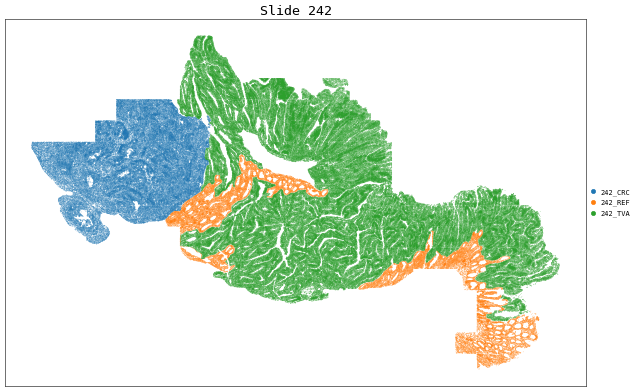

In [21]:
fig, ax = plt.subplots(figsize=(15, 15))  # width x height in inches

sc.pl.spatial(
    adata,
    color=domains_key,
    ax=ax,
    spot_size=100,
    title=f"Slide 242",
    show=False,
)
# Remove x and y axis labels
ax.set_xlabel('')
ax.set_ylabel('')

# Optionally, remove ticks too
ax.set_xticks([])
ax.set_yticks([])
plt.show()

fig.savefig(f"{fig_save_path}/{slide_id}slide.png", bbox_inches='tight')

## Data splits

In [22]:
split = "random"

# Get holdout indices
if split == "random":
    fraction = 0.1
    n_cells = adata.n_obs
    n_holdout = int(n_cells * fraction)

    # Randomly choose cells
    test_idx = np.random.choice(n_cells, n_holdout, replace=False)

elif split == "ood":
    holdout_ct = "Fibroblast"
    is_tumor_region  = adata.obs[domains_key].str.contains("CRC", regex=True)
    is_holdout_ct = adata.obs[labels_key] == holdout_ct

    # Combine for test set
    test_mask = (is_tumor_region) & (is_holdout_ct)
    test_idx = np.where(test_mask)[0]
else:
    raise ValueError(f"Unknown split: {split}")

# Get train/val indices
all_idx = np.arange(adata.n_obs)
trainval_idx = np.setdiff1d(all_idx, test_idx)

In [23]:
# Set 'is_holdout' to False by default, then True for selected cells
adata.obs['is_holdout'] = False
adata.obs.iloc[test_idx, adata.obs.columns.get_loc('is_holdout')] = True

In [24]:
validation_size = 0.1
train_idx, val_idx = train_test_split(
    trainval_idx,
    test_size=validation_size,
    random_state=0,
    shuffle=True,
)

# Train

In [25]:
model_base_path = f"/g/stegle/spiljak/cellina_tutorial/data/models/mark1/{slide_id}"

In [26]:
from scvi.train._callbacks import SaveCheckpoint, EarlyStopping

model_args = {
    'adata': adata,
    'n_latent': 64,
    'n_layers': 3,
    'use_observed_lib_size': True,
    'condition_on_intrinsic': False,
    'gene_likelihood': 'nb',
    'classifier_lambda': 1.,
    'discriminator_lambda': 1.,
    }
train_args = {'max_epochs': 10,
              'batch_size': 4096,
              'check_val_every_n_epoch': 1,
              'early_stopping': True,
              'devices': [0],
              'datasplitter_kwargs': {
                  "external_indexing": [train_idx, val_idx, test_idx],
                  },
              'enable_checkpointing':True,
              'callbacks': [
                  SaveCheckpoint(
                      monitor='vae_loss_validation',
                      dirpath=f"{model_base_path}",
                      load_best_on_end=True,
                      ),
                  EarlyStopping(
                      monitor="vae_loss_validation",
                      patience=5,
                      mode="min",
                    ),
                ],
    }

plan_kwargs = {
    'lr': 1e-3,
    'normalize_losses': True
    }

In [27]:
CellinaModel.setup_anndata(adata,
                           batch_key=batch_key,
                           labels_key=labels_key, 
                           domains_key=domains_key, 
                           spatial_connectivities_key="spatial_connectivities",
                           layer='counts')

/g/stegle/spiljak/programs/miniforge3/envs/cellina-graf/lib/python3.11/site-packages/scvi/data/fields/_layer_field.py:115: UserWarning: Training will be faster when sparse matrix is formatted as CSR. It is safe to cast before model initialization.
  _verify_and_correct_data_format(adata, self.attr_name, self.attr_key)


In [32]:
model = CellinaModel(
    **model_args, 
)
model.train(**train_args, plan_kwargs=plan_kwargs)

INFO     cellina: The Cellina model has been initialized with adversarial domain forgetting with edge prediction   


/g/stegle/spiljak/programs/miniforge3/envs/cellina-graf/lib/python3.11/site-packages/lightning/fabric/plugins/environments/slurm.py:204: The `srun` command is available on your system but is not used. HINT: If your intention is to run Lightning on SLURM, prepend your python command with `srun` like so: srun python /g/stegle/spiljak/programs/miniforge3/envs/cellina-g ...
INFO: GPU available: True (cuda), used: True
2026-05-28 13:39:27 | [INFO] GPU available: True (cuda), used: True
INFO: TPU available: False, using: 0 TPU cores
2026-05-28 13:39:27 | [INFO] TPU available: False, using: 0 TPU cores
INFO: HPU available: False, using: 0 HPUs
2026-05-28 13:39:27 | [INFO] HPU available: False, using: 0 HPUs
/g/stegle/spiljak/programs/miniforge3/envs/cellina-graf/lib/python3.11/site-packages/lightning/fabric/plugins/environments/slurm.py:204: The `srun` command is available on your system but is not used. HINT: If your intention is to run Lightning on SLURM, prepend your python command with `s

Training:   0%|          | 0/10 [00:00<?, ?it/s]

/g/stegle/spiljak/programs/miniforge3/envs/cellina-graf/lib/python3.11/site-packages/lightning/pytorch/utilities/data.py:78: Trying to infer the `batch_size` from an ambiguous collection. The batch size we found is 89869. To avoid any miscalculations, use `self.log(..., batch_size=batch_size)`.
/g/stegle/spiljak/programs/miniforge3/envs/cellina-graf/lib/python3.11/site-packages/lightning/pytorch/utilities/data.py:78: Trying to infer the `batch_size` from an ambiguous collection. The batch size we found is 90053. To avoid any miscalculations, use `self.log(..., batch_size=batch_size)`.
/g/stegle/spiljak/programs/miniforge3/envs/cellina-graf/lib/python3.11/site-packages/lightning/pytorch/utilities/data.py:78: Trying to infer the `batch_size` from an ambiguous collection. The batch size we found is 89623. To avoid any miscalculations, use `self.log(..., batch_size=batch_size)`.
/g/stegle/spiljak/programs/miniforge3/envs/cellina-graf/lib/python3.11/site-packages/lightning/pytorch/utilities

INFO     File                                                                                                      
         /g/stegle/spiljak/cellina_tutorial/data/models/mark1/242/epoch=7-step=1176-vae_loss_validation=626.6674804
         6875/model.pt already downloaded                                                                          


/g/stegle/spiljak/programs/miniforge3/envs/cellina-graf/lib/python3.11/site-packages/scvi/model/base/_save_load.py:76: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model = 

# Inference and clustering

In [28]:
checkpoint_name = "epoch=7-step=1176-vae_loss_validation=626.66748046875"
print(checkpoint_name)

epoch=7-step=1176-vae_loss_validation=626.66748046875


In [29]:
print(model_base_path)
model_base_path = "/g/stegle/spiljak/cellina_tutorial/data/models/mark1/242"
#/g/stegle/spiljak/cellina_tutorial/data/models/mark1/242/epoch=7-step=1176-vae_loss_validation=626.66748046875

/g/stegle/spiljak/cellina_tutorial/data/models/mark1/242


In [30]:
import os
checkpoint_name = os.listdir(f"{model_base_path}")[0]
model = CellinaModel.load(
    "/g/stegle/spiljak/cellina_tutorial/data/models/mark1/242/epoch=7-step=1176-vae_loss_validation=626.66748046875", #f"{model_base_path}/{checkpoint_name}",
    adata=adata,
)

INFO     File                                                                                                      
         /g/stegle/spiljak/cellina_tutorial/data/models/mark1/242/epoch=7-step=1176-vae_loss_validation=626.6674804
         6875/model.pt already downloaded                                                                          


/g/stegle/spiljak/programs/miniforge3/envs/cellina-graf/lib/python3.11/site-packages/lightning/fabric/plugins/environments/slurm.py:204: The `srun` command is available on your system but is not used. HINT: If your intention is to run Lightning on SLURM, prepend your python command with `srun` like so: srun python /g/stegle/spiljak/programs/miniforge3/envs/cellina-g ...
/g/stegle/spiljak/programs/miniforge3/envs/cellina-graf/lib/python3.11/site-packages/scvi/model/base/_save_load.py:76: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary

/g/stegle/spiljak/programs/miniforge3/envs/cellina-graf/lib/python3.11/site-packages/scvi/data/fields/_layer_field.py:115: UserWarning: Training will be faster when sparse matrix is formatted as CSR. It is safe to cast before model initialization.
  _verify_and_correct_data_format(adata, self.attr_name, self.attr_key)


INFO     cellina: The Cellina model has been initialized with adversarial domain forgetting with edge prediction   


In [31]:
adata.obsm['cellina_basal'] = model.get_latent_representation(adata=adata, latent_key='z', batch_size=4096)
adata.obsm['cellina_spatial'] = model.get_latent_representation(adata=adata, latent_key='s', batch_size=4096)
# adata.obsm['cellina_latent'] = model.get_latent_representation(adata=adata, batch_size=4096)

/g/stegle/spiljak/programs/miniforge3/envs/cellina-graf/lib/python3.11/site-packages/scvi/dataloaders/_data_splitting.py:210: UserWarning: Last batch will have a small size of 1samples. Consider changing settings.batch_size or batch_size in model.traincurrently 128 to avoid errors during model training.
  self.n_train, self.n_val = validate_data_split(
/g/stegle/spiljak/programs/miniforge3/envs/cellina-graf/lib/python3.11/site-packages/torch_geometric/loader/neighbor_loader.py:229: UserWarning: The usage of the 'directed' argument in 'NeighborSampler' is deprecated. Use `subgraph_type='induced'` instead.
  neighbor_sampler = NeighborSampler(


### Latent visualization

In [32]:
adata_sub = subsample_adata(adata, fraction=0.5)


In [33]:
sc.pp.neighbors(adata_sub, use_rep='cellina_basal')
sc.tl.umap(adata_sub)

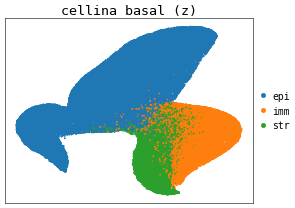

In [34]:
ax = sc.pl.umap(adata_sub, color=[labels_key], wspace=0.3, size=30, legend_fontsize=14, show=False, title="cellina basal (z)")
# Remove x and y axis labels
ax.set_xlabel('')
ax.set_ylabel('')

# Optionally, remove ticks too
ax.set_xticks([])
ax.set_yticks([])

fig = ax.figure
plt.show()

fig.savefig(f"{fig_save_path}/crc_{slide_id}_umap_basal_ct.png", bbox_inches='tight')

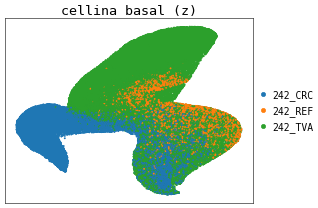

In [35]:
ax = sc.pl.umap(adata_sub, color=[domains_key], wspace=0.3, size=30, legend_fontsize=14, show=False, title="cellina basal (z)")
# Remove x and y axis labels
ax.set_xlabel('')
ax.set_ylabel('')

# Optionally, remove ticks too
ax.set_xticks([])
ax.set_yticks([])

fig = ax.figure
plt.show()

fig.savefig(f"{fig_save_path}/crc_{slide_id}_umap_basal_niche.png", bbox_inches='tight')

In [36]:
sc.pp.neighbors(adata_sub, use_rep='cellina_spatial')
sc.tl.umap(adata_sub)

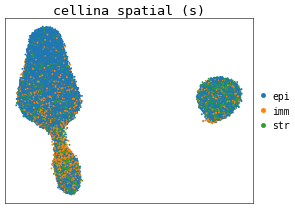

In [37]:
ax = sc.pl.umap(adata_sub, color=[labels_key], wspace=0.3, size=30, legend_fontsize=14, show=False, title="cellina spatial (s)")
# Remove x and y axis labels
ax.set_xlabel('')
ax.set_ylabel('')

# Optionally, remove ticks too
ax.set_xticks([])
ax.set_yticks([])

fig = ax.figure
plt.show()

fig.savefig(f"{fig_save_path}/{slide_id}_umap_spatial_ct.png", bbox_inches='tight')

In [38]:
palette = {
    # Control
    '242_REF': '#E69F00',

    # CRC
    '242_CRC': "#0075D5",

    # TVA
    '242_TVA': "#00B221",
}

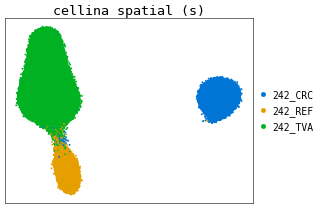

In [39]:
ax = sc.pl.umap(adata_sub, color=[domains_key], wspace=0.3, size=30, legend_fontsize=14, show=False, title="cellina spatial (s)", palette=palette)
# Remove x and y axis labels
ax.set_xlabel('')
ax.set_ylabel('')

# Optionally, remove ticks too
ax.set_xticks([])
ax.set_yticks([])

fig = ax.figure
plt.show()

fig.savefig(f"{fig_save_path}/{slide_id}_umap_spatial_niche.png", bbox_inches='tight')

## Hotspot clusters

In [40]:
import pandas as pd
import decoupler as dc
import hotspot


import sys, importlib

# Remove cached version of the installed plotting package
if 'plotting' in sys.modules:
    del sys.modules['plotting']

# Insert at front so it takes priority over site-packages
sys.path.insert(0, '/g/stegle/spiljak/cellina_tutorial/cellina-reproducibility/scripts')
from plotting import plot_custom_umap

In [41]:
adata_crc = adata[adata.obs[domains_key].str.contains('CRC')].copy()

In [42]:
set_seed(0)  # ensure reproducible hotspot KNN and module detection

In [43]:
hs = hotspot.Hotspot(
    adata_crc,
    layer_key="counts",
    model='danb',
    latent_obsm_key="cellina_spatial",
    umi_counts_obs_key="nCount_RNA"
)

hs.create_knn_graph(
    weighted_graph=False, n_neighbors=30,
)

In [44]:
hs_results = hs.compute_autocorrelations(jobs=24) #computes Morans's I for each LATENT dimension, paralelized across 24 cores

100%|██████████| 3000/3000 [00:09<00:00, 313.75it/s]


In [45]:
# Select the genes with significant autocorrelation, only the top 5%
top_k = 1200
hs_genes = hs_results.loc[hs_results.FDR < 0.05].head(top_k).index

In [46]:
# Compute pair-wise local correlations between these genes
load_lcz = False
base_dir = f'{model_base_path}/{slide_id}'
lcz_path = f'{base_dir}/hotspot_lcz_crc.csv'

if load_lcz:
    lcz = pd.read_csv(lcz_path, index_col=0)
    hs.local_correlation_z = lcz
else:
    lcz = hs.compute_local_correlations(hs_genes, jobs=24)
    os.makedirs(base_dir, exist_ok=True)
    lcz.to_csv(lcz_path)

Computing pair-wise local correlation on 493 features...


100%|██████████| 121278/121278 [03:27<00:00, 584.66it/s]


In [47]:
modules = hs.create_modules(min_gene_threshold=100, core_only=True, fdr_threshold=0.05)

In [48]:
module_scores = hs.calculate_module_scores()

module_scores.head()

Computing scores for 2 modules...


100%|██████████| 2/2 [00:04<00:00,  2.24s/it]


,1,2
c_4_34_269,0.097917,1.221302
c_4_34_290,-1.179001,0.748121
c_4_34_296,2.475534,-0.537072
c_4_34_308,0.351086,2.105046
c_4_34_322,0.585046,0.121194


In [49]:
module_cols = []
for c in module_scores.columns:
    key = f"Module {c}"
    adata_crc.obs[key] = module_scores[c]
    module_cols.append(key)

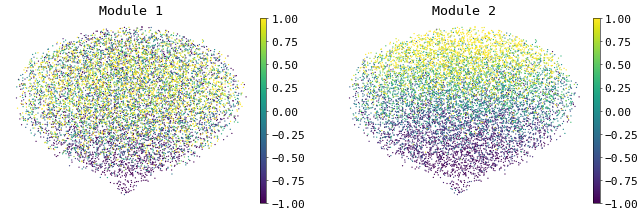

In [50]:
plot_custom_umap(
    adata_crc, subsample=0.1, use_rep='cellina_spatial', color=module_cols,frameon=False, vmin=-1, vmax=1, wspace=0.2
)

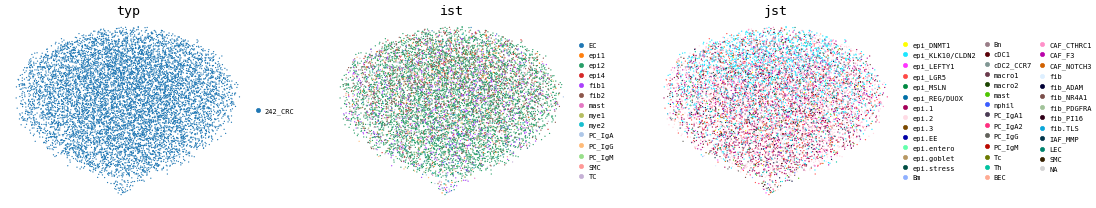

In [51]:
plot_custom_umap(
    adata_crc, subsample=0.1, use_rep='cellina_spatial', color=['typ', 'ist', 'jst'], frameon=False, vmin=-1, vmax=1, wspace=0.2
)

In [52]:
module_scores_epi = module_scores.loc[adata_crc.obs_names]

In [53]:
adata_crc.obsm['module_scores'] = module_scores_epi.values

In [54]:
top_modules = module_scores.idxmax(axis=1)

# Add to adata.obs
adata_crc.obs["top_module"] = top_modules.astype(str)
adata_crc.obs["top_module"] = adata_crc.obs["top_module"].astype("category")

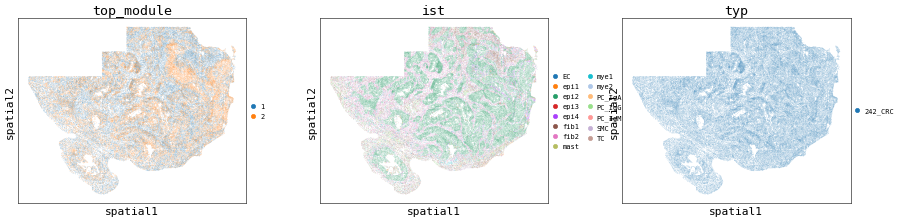

In [55]:
# Plot
sc.pl.spatial(
    adata_crc,
    color=["top_module", "ist", "typ"],
    palette=None,
    spot_size=50,
    show=True
)

In [56]:
# top module to f{CRC{}}
adata_crc.obs['microenvironment'] = adata_crc.obs['top_module'].apply(lambda x: f"CRC{x}")

In [57]:
adata_crc.obs['microenvironment'].value_counts()

microenvironment
CRC1    45571
CRC2    44337
Name: count, dtype: int64

### Remap

In [58]:
typ_map = adata_crc.obs['microenvironment'].astype(str).reindex(adata_sub.obs_names)  # NaN for non-CRC cells

adata_sub.obs['microenvironment'] = pd.Categorical(
    typ_map.fillna(adata_sub.obs['typ'].astype(str))
)

typ_map = adata_crc.obs['microenvironment'].astype(str).reindex(adata.obs_names)  # NaN for non-CRC cells
adata.obs['microenvironment'] = pd.Categorical(
    typ_map.fillna(adata.obs['typ'].astype(str))
)
    

In [59]:
adata.obs['microenvironment'].value_counts()

microenvironment
242_TVA    286784
CRC1        45571
CRC2        44337
242_REF     44002
Name: count, dtype: int64

/scratch/jobs/55115470/ipykernel_230925/333694513.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  celltype_microenv_counts = adata.obs.groupby([labels_key, 'microenvironment']).size().reset_index(name='count')


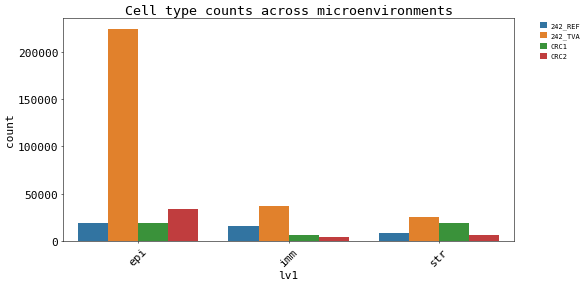

In [60]:
# Plot how many cells of each microenvironment are present in each cell type
celltype_microenv_counts = adata.obs.groupby([labels_key, 'microenvironment']).size().reset_index(name='count')
plt.figure(figsize=(12, 6))
sns.barplot(data=celltype_microenv_counts, x=labels_key, y='count', hue='microenvironment')
plt.xticks(rotation=45)
plt.title("Cell type counts across microenvironments")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

# Counterfactuals - CRC_global vs. CRC_microenv

In [61]:
#celltypes = ['Endothelial', 'Epithelial', 'Fibroblast', 'Myeloid', 'T_cell']
analysis_key = 'lv1' #ili lv1 - na tome je bilo treinirano
celltypes = list(adata.obs[analysis_key].dropna().unique())
microenvironments = [m for m in adata.obs['microenvironment'].unique() if 'CRC' in m]
results = {k: adata[adata.obs[labels_key] == k] for k in celltypes}

In [62]:
print(microenvironments)

['CRC2', 'CRC1']


In [63]:
for ct, ds in results.items():
    print(ct, ds.n_obs)

str 60282
imm 63261
epi 297151


In [64]:
print(adata.obs[labels_key].unique())

['str', 'imm', 'epi']
Categories (3, object): ['epi', 'imm', 'str']


In [ ]:
import gc, torch
  
for ct in tqdm(celltypes, desc="Cell types"):
    # ... your existing loop ...

    # add at the end of each ct iteration:
    torch.cuda.empty_cache()
    gc.collect()

Cell types: 100%|██████████| 3/3 [00:00<00:00,  3.06it/s]


: 

In [66]:
for ct in tqdm(celltypes, desc=f"Cell types"):
    # Control set is same - only target changes (either crc_all or microenv labels)
    is_tumor_region = adata.obs[domains_key].astype(str).str.contains('CRC', regex=True)
    is_celltype = adata.obs[labels_key].astype(str) == ct
    
    mask_control = ~is_tumor_region & is_celltype
    # mask_control = adata.obs[domains_key].astype(str).str.contains('REF', regex=True) & is_celltype # NOTE: changed from ~CRC to REF
    
    idx_control = np.where(mask_control.values)[0]

    # 1. Compute counterfactuals for global crc -- Claude thinks this causes Out Of Memory crash each time so he suggested a bleow part to fix it, we will se
    #mask_target = is_tumor_region
    #idx_target = np.where(mask_target.values)[0] #mask_target = is_tumor_region & is_celltype
    
    # 1. Compute counterfactuals for global crc
    mask_target = is_tumor_region
    idx_target = np.where(mask_target.values)[0]
    rng = np.random.default_rng(0)
    idx_target = rng.choice(idx_target, size=min(10_000, len(idx_target)), replace=False)
    
    args = {
                
                "indices": idx_control,
                "neighbour_indices": idx_target,
                "batch_size": 4096,
                "seed": 0,
            }
    results[ct].obsm['recon_x'] = model.get_normalized_expression(adata=results[ct], batch_size=4096, library_size=1e4)
    results[ct].uns[f'counterfactual_x_global'] = model.get_counterfactual_expression(**args, library_size=1e4)
    results[ct].uns[f'counterfactual_latents_global'] = model.get_counterfactual_latents(**args, latent_key='shifted')

    # 2. Loop over microenvironments
    for microenv in tqdm(microenvironments, desc=f"Microenvironments"):
        is_in_microenv = adata.obs['microenvironment'].astype(str).str.contains(microenv, regex=True)
        mask_target = is_in_microenv
        #mask_target = is_in_microenv & is_celltype
        idx_target = np.where(mask_target.values)[0]
        args["neighbour_indices"] = idx_target
        results[ct].uns[f'counterfactual_x_{microenv}'] = model.get_counterfactual_expression(**args, library_size=1e4)
        results[ct].uns[f'counterfactual_latents_{microenv}'] = model.get_counterfactual_latents(**args, latent_key='shifted')

Cell types:   0%|          | 0/3 [00:00<?, ?it/s]

INFO     Received view of anndata, making copy.                                                                    
INFO     Input AnnData not setup with scvi-tools. attempting to transfer AnnData setup                             


/g/stegle/spiljak/programs/miniforge3/envs/cellina-graf/lib/python3.11/site-packages/scvi/data/fields/_layer_field.py:115: UserWarning: Training will be faster when sparse matrix is formatted as CSR. It is safe to cast before model initialization.
  _verify_and_correct_data_format(adata, self.attr_name, self.attr_key)
/g/stegle/spiljak/programs/miniforge3/envs/cellina-graf/lib/python3.11/site-packages/scvi/dataloaders/_data_splitting.py:210: UserWarning: Last batch will have a small size of 1samples. Consider changing settings.batch_size or batch_size in model.traincurrently 128 to avoid errors during model training.
  self.n_train, self.n_val = validate_data_split(
/g/stegle/spiljak/programs/miniforge3/envs/cellina-graf/lib/python3.11/site-packages/torch_geometric/loader/neighbor_loader.py:229: UserWarning: The usage of the 'directed' argument in 'NeighborSampler' is deprecated. Use `subgraph_type='induced'` instead.
  neighbor_sampler = NeighborSampler(


: 

: 

In [ ]:
# _normalize_counts, safe_log2_fold_change, compute_correlations imported from helpers (cell 2)


In [ ]:
summary = []
deg = 200

for ct, dataset in tqdm(results.items(), desc="Computing correlations"):
    is_tumor_region = adata.obs[domains_key].astype(str).str.contains('CRC', regex=True)
    mask_control = ~dataset.obs[domains_key].astype(str).str.contains('CRC', regex=True)
    # mask_control = dataset.obs[domains_key].astype(str).str.contains('REF', regex=True) # NOTE: change from ~CRC to REF?

    control = dataset.layers['counts'].todense()[mask_control]
    control = np.asarray(control)
    
    is_ct = dataset.obs[labels_key].astype(str) == ct
    #mask_target = is_tumor_region & is_ct
    mask_target = is_tumor_region
    target = adata.layers['counts'].todense()[mask_target]
    target = np.asarray(target)

    counterfactual = dataset.uns['counterfactual_x_global']
    pear_global, spear_global = compute_correlations(control, target, counterfactual, deg=deg)

    summary.append({
        "cell_type": ct,
        "label": "CRC_global",
        "pearson": np.round(pear_global, 4),
        "spearman": np.round(spear_global, 4)
    })

    for microenv in tqdm(microenvironments, desc="Microenvironments"):
        is_in_microenv = adata.obs['microenvironment'].astype(str).str.contains(microenv, regex=True)
        
        #mask_target = is_in_microenv & is_ct
        mask_target = is_in_microenv
        target = adata.layers['counts'].todense()[mask_target]

        target = np.asarray(target)
        counterfactual = dataset.uns[f'counterfactual_x_{microenv}']
        pear_microenv, spear_microenv = compute_correlations(control, target, counterfactual, deg=deg)
        summary.append({
            "cell_type": ct,
            "label": microenv,
            "pearson": np.round(pear_microenv, 4),
            "spearman": np.round(spear_microenv, 4)
        })

In [ ]:
summary_df = pd.DataFrame(summary)

In [ ]:
print(summary_df)

In [ ]:
# Save df
summary_df.to_csv(f"../../results/microenvironments_{slide_id}.csv", index=False)

## Save outputs

In [ ]:
# ── Save Part 1 outputs ────────────────────────────────────────────────────
import pickle, os

os.makedirs("output", exist_ok=True)

# Save annotated AnnData (includes obsm latents + obs microenvironment)
adata.write_h5ad("output/adata_with_microenv.h5ad")
print("Saved adata to output/adata_with_microenv.h5ad")

# Save Hotspot object (modules, results, etc.)
with open("output/hotspot.pkl", "wb") as _f:
    pickle.dump(hs, _f)
print("Saved hotspot to output/hotspot.pkl")

# Save per-cell-type results dict (AnnData objects with .uns counterfactuals)
with open("output/results.pkl", "wb") as _f:
    pickle.dump(results, _f)
print("Saved results dict to output/results.pkl")

print(f"Model checkpoint saved at: {model_base_path}")
